# U23AI035 - LAB 6 - Responsible AI

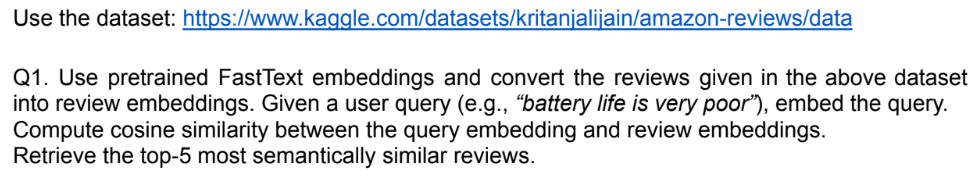

In [1]:
import pandas as pd
import numpy as np
import nltk
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
nltk.download('punkt')
import random
import string

[nltk_data] Downloading package punkt to C:\Users\JAIVAL
[nltk_data]     CHAUHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.columns = ['polarity', 'title', 'text']

In [4]:
df.columns

Index(['polarity', 'title', 'text'], dtype='object')

In [5]:
df.head()

,polarity,title,text
0,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
1,2,Amazing!,This soundtrack is my favorite music of all ti...
2,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
3,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
4,2,an absolute masterpiece,I am quite sure any of you actually taking the...


In [6]:
reviews = df['text'].dropna().tolist()

In [7]:
fasttext_path = "cc.en.300.vec"
ft_model = KeyedVectors.load_word2vec_format(
    fasttext_path, 
    binary=False
)

In [8]:
def sentence_embedding(sentence, model, dim=300):
    words = word_tokenize(sentence.lower())
    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)

In [9]:
review_embeddings = np.array([sentence_embedding(review, ft_model) for review in reviews])

In [10]:
query = "battery life is very poor"
query_embedding = sentence_embedding(query, ft_model).reshape(1, -1)

In [11]:
similarities = cosine_similarity(query_embedding, review_embeddings)[0]

top_indices = similarities.argsort()[-5:][::-1]

print("\nTop 5 Most Similar Reviews:\n")
for idx in top_indices:
    print(f"Similarity: {similarities[idx]:.4f}")
    print(f"Review: {reviews[idx]}")
    print("-" * 80)


Top 5 Most Similar Reviews:

Similarity: 0.8902
Review: The animation is very very poor and quite ugly but the story is entertaining and the thief is super hillarious.
--------------------------------------------------------------------------------
Similarity: 0.8841
Review: the video is made with very very poor quality,the sound is poor and the picture is blurred..
--------------------------------------------------------------------------------
Similarity: 0.8690
Review: The thing is not bad, but the battery run out very quickly and is very bulky also
--------------------------------------------------------------------------------
Similarity: 0.8683
Review: it's a very good camera but is small and very portable and your resolution is very good....
--------------------------------------------------------------------------------
Similarity: 0.8669
Review: For a Jazz lover this is fabilous disk.Music is great.SACD sound quality is very very good.
----------------------------------------

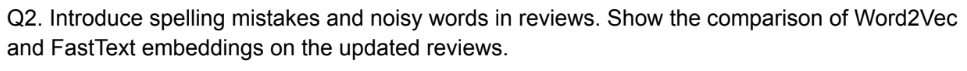

In [12]:
def add_noise(text, prob=0.2):
    words = text.split()
    noisy_words = []

    for word in words:
        if random.random() < prob:
            noise_type = random.choice(["delete", "swap", "elongate", "random"])

            if noise_type == "delete" and len(word) > 3:
                i = random.randint(0, len(word)-1)
                word = word[:i] + word[i+1:]

            elif noise_type == "swap" and len(word) > 3:
                i = random.randint(0, len(word)-2)
                word = word[:i] + word[i+1] + word[i] + word[i+2:]

            elif noise_type == "elongate":
                word = word + random.choice(["", "yy", "zzz"])

            elif noise_type == "random":
                word = word + random.choice(string.ascii_lowercase)

        noisy_words.append(word)

    return " ".join(noisy_words)

In [13]:
noisy_reviews = [add_noise(review) for review in reviews]

In [14]:
word2vec = KeyedVectors.load('word2vec-google-news-300.model')

In [15]:
fasttext = ft_model

In [16]:
w2v_embeddings = np.array([sentence_embedding(review, word2vec) for review in noisy_reviews])

In [17]:
ft_embeddings = np.array([sentence_embedding(review, fasttext) for review in noisy_reviews])

In [18]:
query = "battery life is very poor"
query_w2v = sentence_embedding(query, word2vec).reshape(1, -1)
query_ft = sentence_embedding(query, fasttext).reshape(1, -1)

sim_w2v = cosine_similarity(query_w2v, w2v_embeddings)[0]
sim_ft = cosine_similarity(query_ft, ft_embeddings)[0]

top_w2v = sim_w2v.argsort()[-5:][::-1]
top_ft = sim_ft.argsort()[-5:][::-1]

In [19]:
print("=== Word2Vec Results (Noisy Reviews) ===\n")
for i in top_w2v:
    print(f"Similarity: {sim_w2v[i]:.4f}")
    print(noisy_reviews[i])
    print("-"*70)

print("\n=== FastText Results (Noisy Reviews) ===\n")
for i in top_ft:
    print(f"Similarity: {sim_ft[i]:.4f}")
    print(noisy_reviews[i])
    print("-"*70)

=== Word2Vec Results (Noisy Reviews) ===

Similarity: 0.8517
Works as advertised.k Battery life is equal, ifb notzzz superior, to the origial battery. A very good deal.
----------------------------------------------------------------------
Similarity: 0.8314
It is a battery a good battery It is a goodzzz battery IT IS A OGOD BATTERY It is a good battery It is a good battery
----------------------------------------------------------------------
Similarity: 0.8176
The battery was dleivered promptlyyy and is a Nokia branded battery. Apparently an old battery or stored incorrectly. Battery life of my original batery was adys. Battery life of this battery is aout one day in stand-by mode only, shorter life if talk time added in.
----------------------------------------------------------------------
Similarity: 0.8002
poor build quality, battery life and there are no gamesyy included. warningj do not buy.and battery life is evenzzz worse when you use the bluetooth.I evenr bought the etxended

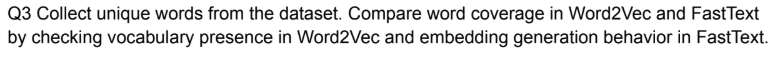

In [20]:
unique_words = set()

for review in reviews:
    tokens = word_tokenize(review.lower())
    unique_words.update(tokens)

print("Total unique words in dataset:", len(unique_words))

Total unique words in dataset: 2001412


In [21]:
w2v_vocab = set(word2vec.key_to_index.keys())

in_vocab_w2v = [word for word in unique_words if word in w2v_vocab]
oov_w2v = [word for word in unique_words if word not in w2v_vocab]

print("Word2Vec In-Vocabulary Words:", len(in_vocab_w2v))
print("Word2Vec OOV Words:", len(oov_w2v))

coverage_w2v = len(in_vocab_w2v) / len(unique_words) * 100
print(f"Word2Vec Vocabulary Coverage: {coverage_w2v:.2f}%")

Word2Vec In-Vocabulary Words: 119400
Word2Vec OOV Words: 1882012
Word2Vec Vocabulary Coverage: 5.97%


In [22]:
def can_fasttext_embed(word, model):
    try:
        vec = model[word]
        return True
    except KeyError:
        return False

In [23]:
fasttext_success = sum(can_fasttext_embed(w, fasttext) for w in oov_w2v)

print("FastText embeddings generated for Word2Vec OOV words:", fasttext_success)
print("Total Word2Vec OOV words:", len(oov_w2v))

FastText embeddings generated for Word2Vec OOV words: 190713
Total Word2Vec OOV words: 1882012


In [25]:
sample_oov = oov_w2v[:10]

print("Sample OOV words (Word2Vec):")
for word in sample_oov:
    if word in fasttext.key_to_index:
        print(f"{word} → FastText vector norm: {np.linalg.norm(fasttext[word]):.4f}")
    else:
        print(f"{word} → Not present in loaded FastText vocabulary")

Sample OOV words (Word2Vec):
md.thanks → Not present in loaded FastText vocabulary
accessories. → FastText vector norm: 0.5211
lytton → FastText vector norm: 1.1516
pateman → Not present in loaded FastText vocabulary
antibalas → Not present in loaded FastText vocabulary
scared7 → Not present in loaded FastText vocabulary
bream/barrueco → Not present in loaded FastText vocabulary
sucj → Not present in loaded FastText vocabulary
site.sandra → Not present in loaded FastText vocabulary
loureiro → Not present in loaded FastText vocabulary
